# Issue #4 — Threaded Through, Credited Nowhere.

**Pillar:** 3 (who actually gets paid)

**Story:** A $25 t-shirt. Follow the dollar through the supply chain and see who actually gets a piece of
it, the store, the brand, the materials, the shipping, the factory owner, and finally, the person who
sewed it. The workers cut the fabric. They don't get a cut of the price.

**Scope:**
- Data: Clean Clothes Campaign's published price-breakdown percentages (retailer, brand profit,
  materials, transport, factory profit, worker wages), corroborated independently by a Statista chart
  and a War on Want report that cites CCC directly with matching euro figures
- Anchor: composite hypothetical garment (not a real branded item), price point set at $25 USD
- Chart 5.1: pie chart, full price split into labeled segments, built as two separate files (chart and
  legend) rather than one combined image, with all slide text left out for Canva
- Chart 5.2: a second, standalone diagram, Bangladesh's legal minimum wage against the actual cost of
  living for a Dhaka family, sourced from Public Eye & Clean Clothes Campaign's "Squeezed Dry" report
  (May 2026)
- Original CCC percentages (5.1) sum to ~96.6%, not 100%. The ~3.4% gap is treated honestly as
  "unaccounted / rounding in CCC's original published figures" rather than folded into another category

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

ISSUE = "issue-04"
DATA_OUT = Path(f"../../data/processed/issue-04-threaded-through-credited-nowhere")
CHART_OUT = Path(f"../../content/posts/issue-04-threaded-through-credited-nowhere/exports")
DATA_OUT.mkdir(parents=True, exist_ok=True)
CHART_OUT.mkdir(parents=True, exist_ok=True)

In [3]:
import os
print(os.environ.get("MPLBACKEND"))

module://matplotlib_inline.backend_inline


## 2. Load palette

In [19]:
# load brand palette
with open("../../brand/palette.json") as f:
    palette_data = json.load(f)

palette = {c["name"]: c["hex"] for c in palette_data["palette"]}

COCOA = palette["Cocoa"]
DUSTY = palette["Dusty"]
PEACH = palette["Peach"]
CREAM = palette["Cream"]
SAGE  = palette["Sage"]

# issue #4: cream background, cocoa-colored text for charts
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.facecolor"] = CREAM
plt.rcParams["figure.facecolor"] = CREAM

## 3. Sourcing: the price breakdown

No API pull is needed for this issue, the core data is Clean Clothes Campaign's published percentage breakdown
of a retail garment price, not a live series. Logged here as the "manual input" in the same spirit as
prior issues' manual_inputs blocks, with full citation trail.

In [3]:
manual_inputs = {
    "ccc_price_breakdown": {
        "value_pct": {
            "Retailer": 60.0,
            "Brand profit": 12.0,
            "Materials": 12.0,
            "Transport": 8.0,
            "Factory profit": 4.0,
            "Worker wages": 0.6,
        },
        "label": 'Breakdown of the retail price of a €29 T-shirt, made in Bangladesh, sold in Europe',
        "source": "Clean Clothes Campaign (original campaign infographic; live page since reorganized)",
        "corroborating_sources": [
            {
                "name": "Statista chart citing Clean Clothes Campaign",
                "url": "https://www.statista.com/chart/34514/breakdown-of-the-retail-price-of-a-t-shirt",
            },
            {
                "name": "War on Want, \"The global impact of the fashion industry\", citing Clean Clothes "
                        "Campaign directly with matching € figures (brand profit and materials each "
                        "€3.61 / 12%, worker wages €0.18 / 0.6%)",
                "url": "https://waronwant.org/fashioning-future/global-impact-fashion-industry",
            },
        ],
        "date_accessed": "2026-08-14",
        "notes": "Original CCC percentages sum to ~96.6%, not 100%. Treated the ~3.4% gap as 'unaccounted / rounding in CCC's original published figures' rather than silently folding it into another category. Original data is denominated in EUR for a specific €29 T-shirt; applied here as PERCENTAGES (not a currency conversion of that exact item) to a $25 USD hypothetical composite garment, per locked scope.",
    },
    "recent_context_stat": {
        "value": "Brands are paying roughly 30%  less in real terms for a cotton T-shirt sourced from "
                 "Bangladesh than they did 25 years ago, even as retail prices have not fallen "
                 "commensurately",
        "label": "Recent trend context (caption/background only, NOT plotted in the main chart)",
        "source": "Public Eye & Clean Clothes Campaign, \"Squeezed Dry\" report, May 2026",
        "source_url": "https://www.publiceye.ch/fileadmin/doc/Mode/2026_Squeezed_Dry/PE_Report_CCC-Pricing_5-26_E.pdf",
        "date_accessed": "2026-08-14",
        "note": "Measures a DIFFERENT quantity than the main chart (share of EXPORT/FOB price paid to the "
                "factory, not share of full retail price). Not comparable to the retailer/brand/materials "
                "breakdown above, kept separate. Useful as caption context: the squeeze has gotten worse "
                "since the CCC breakdown above was calculated, not better, so treat that breakdown as a "
                "reasonable current estimate rather than a stale worst-case.",
    },
}

manual_inputs

{'ccc_price_breakdown': {'value_pct': {'Retailer': 60.0,
   'Brand profit': 12.0,
   'Materials': 12.0,
   'Transport': 8.0,
   'Factory profit': 4.0,
   'Worker wages': 0.6},
  'label': 'Breakdown of the retail price of a €29 T-shirt, made in Bangladesh, sold in Europe',
  'source': 'Clean Clothes Campaign (original campaign infographic; live page since reorganized)',
  'corroborating_sources': [{'name': 'Statista chart citing Clean Clothes Campaign',
    'url': 'https://www.statista.com/chart/34514/breakdown-of-the-retail-price-of-a-t-shirt'},
   {'name': 'War on Want, "The global impact of the fashion industry", citing Clean Clothes Campaign directly with matching € figures (brand profit and materials each €3.61 / 12%, worker wages €0.18 / 0.6%)',
    'url': 'https://waronwant.org/fashioning-future/global-impact-fashion-industry'}],
  'date_accessed': '2026-08-14',
  'notes': "Original CCC percentages sum to ~96.6%, not 100%. Treated the ~3.4% gap as 'unaccounted / rounding in CCC's

## 4. Build the breakdown + sanity check

Applies to the souced percentages to the locked $25 price point and checks the total since CCC's own published figures sum to ~96.6%.

In [4]:
price = 25.00

pct = manual_inputs["ccc_price_breakdown"]["value_pct"]
accounted_pct = sum(pct.values())
gap_pct = round(100 - accounted_pct, 2)

breakdown = pd.DataFrame([
    {"category": "Retailer",                 "pct": pct["Retailer"]},
    {"category": "Brand profit",             "pct": pct["Brand profit"]},
    {"category": "Materials",                "pct": pct["Materials"]},
    {"category": "Transport",                "pct": pct["Transport"]},
    {"category": "Factory profit",           "pct": pct["Factory profit"]},
    {"category": "Unaccounted / rounding",   "pct": gap_pct},
    {"category": "Worker wages",             "pct": pct["Worker wages"]},
])
breakdown["usd"] = (breakdown["pct"] / 100 * price).round(2)

usd_col = "usd"
print(f"Accounted for by CCC's own figures: {accounted_pct}%")
print(f"Gap (unaccounted/rounding): {gap_pct}%")
print(f"Dollar sum check: ${breakdown[usd_col].sum():.2f} (should equal ${price:.2f})")
breakdown

Accounted for by CCC's own figures: 96.6%
Gap (unaccounted/rounding): 3.4%
Dollar sum check: $25.00 (should equal $25.00)


,category,pct,usd
0,Retailer,60.0,15.00
1,Brand profit,12.0,3.00
2,Materials,12.0,3.00
3,Transport,8.0,2.00
4,Factory profit,4.0,1.00
5,Unaccounted / rounding,3.4,0.85
6,Worker wages,0.6,0.15


In [5]:
# save the ouput into ../../data/processed

breakdown.to_csv(DATA_OUT / "price_breakdown_processed.csv", index=False)
print(f"Saved to {DATA_OUT / 'price_breakdown_processed.csv'}")

Saved to ..\..\data\processed\issue-04-threaded-through-credited-nowhere\price_breakdown_processed.csv


## 5. Charting

Two diagrams for this issue: 
- Chart 1: the price breakdown of the hypothetical $25 garment
- Chart 2: a supporting snapshot on the wage side of the story

### 5.1 Chart 1 : Price breakdown (pie chart)

The full $25 price split into a pie chart, showing where each dollar actually goes: retailer, brand profit, materials, transport, factory profit, and worker wages.

Built as two separate image files, chart and legend, rather than one combined image, since combining them caused the legend to overlap.

All slide text (title, slice labels, tiny-slice callout) is intentionally left out of the chart itself, kept commented out in the code below, since that text will be added directly in Canva instead.

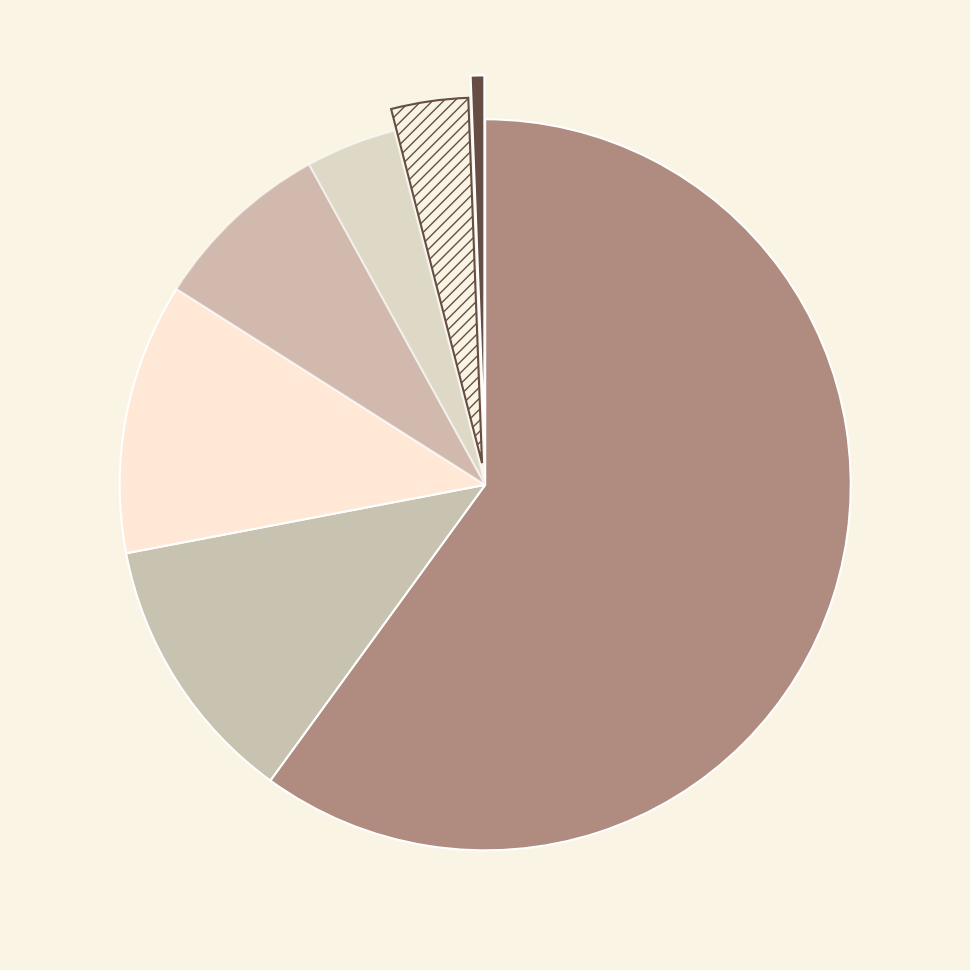

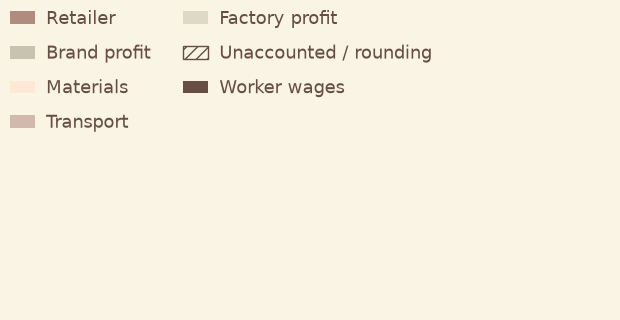

In [ ]:
FIG_SIZE_IN = 10.8
DPI = 100

# pie chart, standalone
fig1 = plt.figure(figsize=(FIG_SIZE_IN, FIG_SIZE_IN), dpi=DPI)
fig1.patch.set_facecolor(CREAM)
ax1 = fig1.add_axes([0.06, 0.06, 0.88, 0.88])
ax1.set_facecolor(CREAM)

colors = breakdown["color"].tolist() if "color" in breakdown else [
    DUSTY, SAGE, PEACH, DUSTY, SAGE, CREAM, COCOA
]
alphas = [1.0, 1.0, 1.0, 0.55, 0.55, 1.0, 1.0]
hatches = ["///" if c == "Unaccounted / rounding" else None for c in breakdown["category"]]
explode = [0.0] * 5 + [0.06, 0.12]

wedges, _ = ax1.pie(
    breakdown["pct"], colors=colors, startangle=90, counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}, explode=explode,
    radius=1.0,
)
for w, a, h in zip(wedges, alphas, hatches):
    w.set_alpha(a)
    if h:
        w.set_hatch(h)
        w.set_edgecolor(COCOA)

ax1.set_xlim(-1.3, 1.3)
ax1.set_ylim(-1.3, 1.3)
ax1.set_aspect("equal")
ax1.axis("off")

fig1.savefig(CHART_OUT / "price_breakdown_pie_only.png", dpi=DPI, facecolor=CREAM)
plt.show()

# legend, standalone
fig2 = plt.figure(figsize=(6, 3))
fig2.patch.set_facecolor(CREAM)
ax2 = fig2.add_axes([0, 0, 1, 1])
ax2.axis("off")
ax2.set_facecolor(CREAM)

legend_handles = [
    mpatches.Patch(facecolor=c, alpha=a,
                   edgecolor=(COCOA if cat == "Unaccounted / rounding" else "none"),
                   hatch=("///" if cat == "Unaccounted / rounding" else None),
                   label=cat)
    for cat, c, a in zip(breakdown["category"], colors, alphas)
]
legend = ax2.legend(handles=legend_handles, loc="upper left", ncol=2, frameon=False,
                     labelcolor=COCOA, fontsize=13, handlelength=1.4,
                     columnspacing=1.8, handletextpad=0.6, labelspacing=0.9,
                     borderaxespad=0, borderpad=0)

fig2.canvas.draw()
bbox_inches = legend.get_window_extent().transformed(fig2.dpi_scale_trans.inverted())
fig2.savefig(CHART_OUT / "price_breakdown_legend_only.png", dpi=100, facecolor=CREAM,
             bbox_inches=bbox_inches, pad_inches=0.15)
plt.show()

### 5.2 Chart 2: Minimum wage vs. Cost of living

A second, standalone diagram giving the "who absorbs it" beat its own supporting data point:
Bangladesh's legal minimum wage against the actual cost of living for a family in Dhaka.

**Source**: Public Eye & Clean Clothes Campaign, "Squeezed Dry: Pricing pressure in the global
fashion industry" (May 2026). Minimum wage figure (BDT 12,500, ~USD 105) and the Dhaka
family cost-of-living figure (BDT 48,022, from the Anker Research Institute's 2025 estimate,
cited in the report) both come directly from the report. The USD conversion for the cost-of-living
figure is NOT stated in the report; it's computed here using the same implied exchange rate
(~119 BDT/USD) the report itself used for the minimum wage figure, so both numbers sit on a
consistent conversion basis. 

In [20]:
wage_gap_inputs = {
    "bangladesh_min_wage": {
        "bdt": 12500,
        "usd": 105,  # as directly stated in the report
        "label": "Legal minimum wage, Bangladesh RMG sector",
    },
    "dhaka_cost_of_living": {
        "bdt": 48022,
        "usd": None,  # not stated in the report; computed below using the implied rate
        "label": "Cost of living for a Dhaka family (Anker Research Institute, 2025 estimate)",
    },
    "source": "Public Eye & Clean Clothes Campaign, \"Squeezed Dry: Pricing pressure in the "
              "global fashion industry\", May 2026, p.24",
    "source_url": "https://www.publiceye.ch/fileadmin/doc/Mode/2026_Squeezed_Dry/PE_Report_CCC-Pricing_5-26_E.pdf",
    "date_accessed": "2026-08-14",
}

implied_rate = wage_gap_inputs["bangladesh_min_wage"]["bdt"] / wage_gap_inputs["bangladesh_min_wage"]["usd"]
wage_gap_inputs["dhaka_cost_of_living"]["usd"] = round(
    wage_gap_inputs["dhaka_cost_of_living"]["bdt"] / implied_rate, 2
)

print(f"Implied exchange rate: {implied_rate:.2f} BDT per USD")
print(f"Dhaka cost of living in USD: ${wage_gap_inputs['dhaka_cost_of_living']['usd']:.2f}/month")
print(f"Ratio: {wage_gap_inputs['dhaka_cost_of_living']['bdt'] / wage_gap_inputs['bangladesh_min_wage']['bdt']:.2f}x")

wage_gap_inputs

Implied exchange rate: 119.05 BDT per USD
Dhaka cost of living in USD: $403.38/month
Ratio: 3.84x


{'bangladesh_min_wage': {'bdt': 12500,
  'usd': 105,
  'label': 'Legal minimum wage, Bangladesh RMG sector'},
 'dhaka_cost_of_living': {'bdt': 48022,
  'usd': 403.38,
  'label': 'Cost of living for a Dhaka family (Anker Research Institute, 2025 estimate)'},
 'source': 'Public Eye & Clean Clothes Campaign, "Squeezed Dry: Pricing pressure in the global fashion industry", May 2026, p.24',
 'source_url': 'https://www.publiceye.ch/fileadmin/doc/Mode/2026_Squeezed_Dry/PE_Report_CCC-Pricing_5-26_E.pdf',
 'date_accessed': '2026-08-14'}

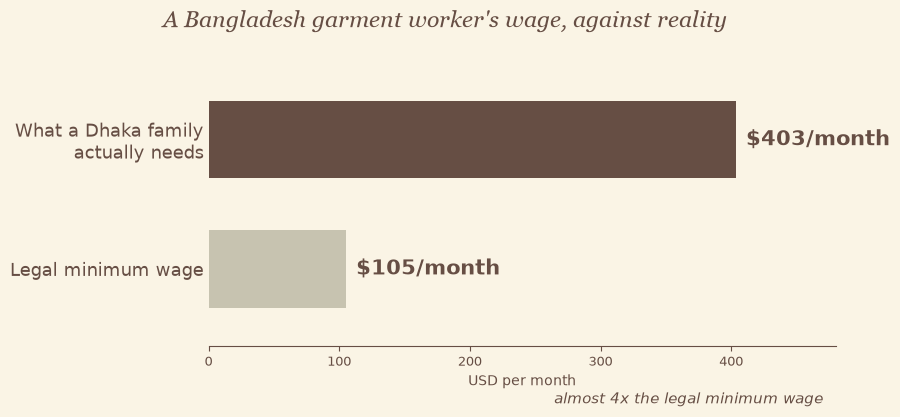

In [22]:
wage_gap = pd.DataFrame([
    {"label": "Legal minimum wage",                 "usd": wage_gap_inputs["bangladesh_min_wage"]["usd"], "color": SAGE},
    {"label": "What a Dhaka family\nactually needs", "usd": wage_gap_inputs["dhaka_cost_of_living"]["usd"], "color": COCOA},
])

fig3, ax3 = plt.subplots(figsize=(9, 4.2))
fig3.patch.set_facecolor(CREAM)
ax3.set_facecolor(CREAM)

y_positions = [0, 1]  # tight spacing, one unit apart
bars = ax3.barh(y_positions, wage_gap["usd"], color=wage_gap["color"], height=0.6)

for bar, val, y in zip(bars, wage_gap["usd"], y_positions):
    ax3.text(val + 8, y, f"${val:,.0f}/month", va="center", ha="left",
              color=COCOA, fontsize=15, fontweight="bold")

fig3.suptitle("A Bangladesh garment worker's wage, against reality", color=COCOA, fontsize=16.5,
              fontstyle="italic", fontfamily="Georgia", y=1.0)

ratio = wage_gap_inputs["dhaka_cost_of_living"]["bdt"] / wage_gap_inputs["bangladesh_min_wage"]["bdt"]
ax3.text(0.98, -0.20, f"almost {ratio:.0f}x the legal minimum wage", transform=ax3.transAxes,
          color=COCOA, fontsize=11, ha="right", style="italic")

ax3.set_xlim(0, 480)
ax3.set_ylim(-0.6, 1.6)
ax3.set_xlabel("USD per month", color=COCOA, fontsize=10)
ax3.set_yticks(y_positions)
ax3.set_yticklabels(wage_gap["label"], fontsize=13, color=COCOA)
ax3.tick_params(axis="x", colors=COCOA, labelsize=9)
ax3.tick_params(axis="y", length=0)
ax3.spines[["top", "right", "left"]].set_visible(False)
ax3.spines["bottom"].set_color(COCOA)

plt.tight_layout()
fig3.savefig(CHART_OUT / "wage_gap_snapshot.png", dpi=200, facecolor=CREAM, bbox_inches="tight")
plt.show()

## 6. Findings

- **The headline number:** on a $25 t-shirt, the person who made it receives about $0.15, 0.6% of the
  price. That's the number the whole issue hangs on.

- **Where the rest actually goes:** the retailer takes the largest single share (60%, $15.00, covering
  store profit, staff, rent, and sales tax), more than the brand, materials, transport, and factory
  combined. Brand profit and materials are tied at 12% each ($3.00 apiece). Transport is 8% ($2.00).
  The factory itself, as a business, keeps 4% ($1.00), more than six times what it pays the worker who
  did the sewing.

- **Data honesty note:** CCC's own published percentages only sum to ~96.6%. Rather than force a clean
  100% by inflating another category, that ~3.4% gap is shown as its own labeled, hatched segment
  ("unaccounted / rounding") in the 5.1 pie chart, so nothing on the chart is invented.

- **5.2 finding (wage gap):** Bangladesh's legal minimum wage (~$105/month) sits at roughly a quarter
  of what the Anker Research Institute estimates a Dhaka family actually needs (~$403/month, our own
  conversion from the report's BDT figure). This reinforces 5.1's finding from a completely different
  angle, not just "the worker's slice of one t-shirt's price is tiny," but "the wage that slice
  represents doesn't come close to covering real living costs."

- **Currency/vintage note:** the 5.1 price-breakdown data is from an older CCC dataset (originally
  EUR, a specific €29 T-shirt); its PERCENTAGES were applied to a $25 USD hypothetical composite
  garment. The May 2026 Public Eye/CCC "Squeezed Dry" report (source for 5.2, and referenced here for
  context) shows sourcing prices for Bangladesh-made T-shirts have dropped roughly 30-50% in real
  terms over 25 years depending on the inflation measure used, suggesting today's worker share is
  likely similar or worse, not better, than what 5.1 shows.

- **Does the data support the hypothesis?** Yes, from two independent angles. "Who actually gets paid"
  points at a disproportionately small worker share in the price breakdown (5.1), and the wage-gap
  snapshot (5.2) confirms that even that small share, in absolute terms, falls far short of a livable
  wage.